In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset_07_student_placement_eligibility.csv")
print(df.shape)
print(df.dtypes)
df.describe()

(1000, 7)
cgpa                  float64
attendance_pct        float64
coding_score            int64
projects_completed      int64
internship_months       int64
backlogs                int64
target                  int64
dtype: object


,cgpa,attendance_pct,coding_score,projects_completed,internship_months,backlogs,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,7.262610,50.859510,2.999000,2.976000,30.539000,2.988000,0.50000
std,1.255403,20.161735,1.711119,1.749424,17.195935,1.722447,0.50025
min,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000
25%,6.470000,37.447500,2.000000,2.000000,16.000000,2.000000,0.00000
50%,7.270000,50.595000,3.000000,3.000000,30.000000,3.000000,0.50000
75%,8.102500,64.027500,4.000000,4.000000,46.000000,4.000000,1.00000
max,10.000000,100.000000,10.000000,9.000000,60.000000,9.000000,1.00000


In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["target"].value_counts())

cgpa                  0
attendance_pct        0
coding_score          0
projects_completed    0
internship_months     0
backlogs              0
target                0
dtype: int64
0
target
1    500
0    500
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only, never fit againy

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

Accuracy: 0.7
Precision: 0.6886792452830188
Recall: 0.73
F1-score: 0.7087378640776699
ROC-AUC: 0.7873999999999999


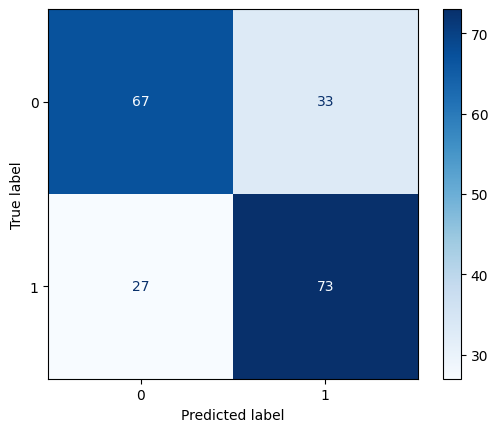

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

In [ ]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(coefs)

coding_score         -0.517072
cgpa                 -0.462246
internship_months    -0.395385
projects_completed    0.551368
attendance_pct        0.556093
backlogs              0.618049
dtype: float64


In [ ]:

# Interactive prediction — type in a student's details, get Yes/No

print("Enter student details to check placement eligibility:\n")

cgpa = float(input("CGPA (0-10): "))
attendance_pct = float(input("Attendance % (0-100): "))
coding_score = float(input("Coding score (0-10): "))
projects_completed = float(input("Projects completed: "))
internship_months = float(input("Internship months: "))
backlogs = float(input("Backlogs: "))

new_student = pd.DataFrame([{
    "cgpa": cgpa,
    "attendance_pct": attendance_pct,
    "coding_score": coding_score,
    "projects_completed": projects_completed,
    "internship_months": internship_months,
    "backlogs": backlogs
}])

new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

print("\n--- Result ---")
if prediction == 1:
    print(f"Prediction: YES (Eligible)  |  Confidence: {probability[1]*100:.1f}%")
else:
    print(f"Prediction: NO (Not Eligible)  |  Confidence: {probability[0]*100:.1f}%")

Enter student details to check placement eligibility:

